# Deep Learning LSTM and Transformer

input : DS-D dataset train.csv and test.csv

### 1. Import Library

In [12]:
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### 2. Data Loading & Windowing Strategy

In [13]:
# Configuration
PROCESSED_DIR = Path("../data/experiments/DS-D")
WINDOW_SIZE = 30
BATCH_SIZE = 64
EPOCHS = 50
FEATURES = ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 
            's_14', 's_15', 's_17', 's_20', 's_21', 'health_index'] 
# Note: Add your rolling mean/std columns to FEATURES if you want to include them.

def create_sequences(data, seq_length, target_col='RUL_clipped'):
    sequences = []
    targets = []
    
    # Identify feature columns (everything except unit_number and target)
    feature_cols = [c for c in data.columns if c not in ['unit_number', target_col]]
    
    for unit in data['unit_number'].unique():
        unit_data = data[data['unit_number'] == unit]
        
        # We need at least 'seq_length' rows to create one sequence
        if len(unit_data) >= seq_length:
            unit_values = unit_data[feature_cols].values
            target_values = unit_data[target_col].values
            
            for i in range(len(unit_data) - seq_length):
                sequences.append(unit_values[i : i + seq_length])
                targets.append(target_values[i + seq_length])
                
    return np.array(sequences), np.array(targets)

# Load data
train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test.csv")

# Scaling (CRITICAL for Deep Learning)
scaler = StandardScaler()
features = [c for c in train_df.columns if c not in ['unit_number', 'RUL_clipped']]
train_df[features] = scaler.fit_transform(train_df[features])
test_df[features] = scaler.transform(test_df[features])

# Generate Sequences
SEQUENCE_LENGTH = 30
X_train, y_train = create_sequences(train_df, SEQUENCE_LENGTH)
X_test, y_test = create_sequences(test_df, SEQUENCE_LENGTH)

print(f"Train sequences: {X_train.shape}, Labels: {y_train.shape}")

class RULDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(RULDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(RULDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

Train sequences: (17631, 30, 113), Labels: (17631,)


### 3. The LSTM Model Architecture

In [14]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :]) # Take last time step
        return out

input_dim = X_train.shape[2] 
model = LSTMModel(input_dim, hidden_dim=64, num_layers=2, output_dim=1).to(device)

### 5. Training & Evaluation Logic

In [15]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 30
for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs.squeeze(), batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")

Epoch [5/30], Loss: 1263.1814
Epoch [10/30], Loss: 132.4722
Epoch [15/30], Loss: 11.8638
Epoch [20/30], Loss: 2.5397
Epoch [25/30], Loss: 1.3110
Epoch [30/30], Loss: 0.7208


### 6. Run and Visualisation

Final Test RMSE: 17.36


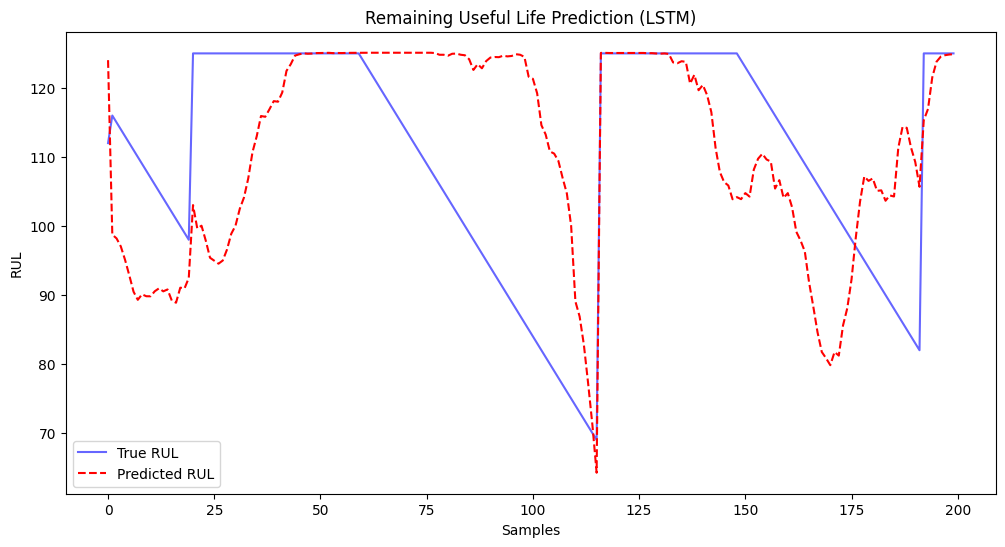

In [16]:
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        predictions.extend(outputs.squeeze().cpu().numpy())
        actuals.extend(batch_y.numpy())

rmse = np.sqrt(mean_squared_error(actuals, predictions))
print(f"Final Test RMSE: {rmse:.2f}")

# Visualize first 100 samples
plt.figure(figsize=(12, 6))
plt.plot(actuals[:200], label='True RUL', color='blue', alpha=0.6)
plt.plot(predictions[:200], label='Predicted RUL', color='red', linestyle='--')
plt.title('Remaining Useful Life Prediction (LSTM)')
plt.xlabel('Samples')
plt.ylabel('RUL')
plt.legend()
plt.show()